# EE 451: Communications Systems
## Lesson 4 - Fourier Analysis Applications

### Learning Objectives
By the end of this lesson, you will be able to:
- Apply Parseval's theorem to relate time-domain energy to frequency-domain energy
- Calculate and interpret energy spectral density for communication signals
- Compute autocorrelation and cross-correlation of signals
- Explain the Wiener-Khinchin theorem relating correlation to power spectral density
- Analyze spectral characteristics of common modulation waveforms

### Textbook Reference
Haykin & Moher, Chapter 2.2-2.5

In [1]:
# Setup: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq, fftshift
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

print("Setup complete!")

Setup complete!


## 1. Parseval's Theorem

**Energy in Time vs. Frequency Domain**

Time domain energy:
$$E = \int_{-\infty}^{\infty} |x(t)|^2 dt$$

Frequency domain energy:
$$E = \int_{-\infty}^{\infty} |X(f)|^2 df$$

**Parseval's Theorem:** These are equal! Total energy is conserved when transforming between domains.

Analytical: E = A²T = 2.0² × 1.0 = 4.00 J
Time domain (numerical):  E = ∫|x(t)|² dt = 4.0020 J
Freq domain (numerical):  E = ∫|X(f)|² df = 4.0020 J

Parseval's theorem verified: 4.0020 ≈ 4.0020 ✓


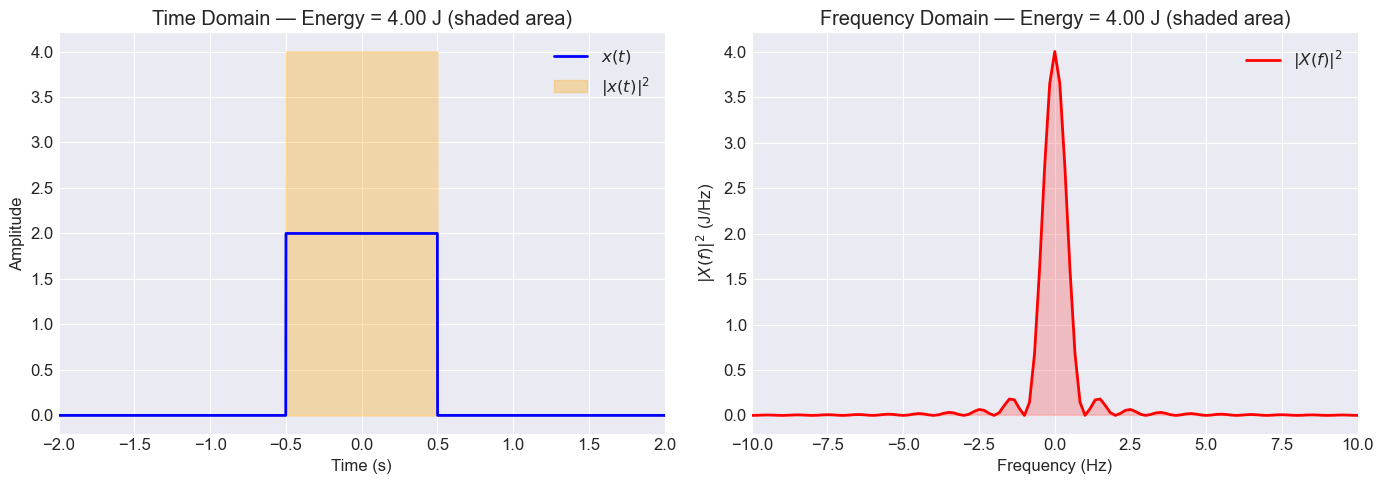


Key Insight: Energy can be computed in whichever domain is easier.
For this pulse, the time-domain integral is trivial: E = A²T = 4 J.


In [2]:
# Worked Example: Parseval's theorem for a rectangular pulse
A = 2.0   # Amplitude (V)
T = 1.0   # Duration (s)

# --- Analytical ---
E_analytical = A**2 * T
print(f"Analytical: E = A²T = {A}² × {T} = {E_analytical:.2f} J")

# --- Numerical verification ---
N = 4096
t = np.linspace(-3, 3, N, endpoint=False)
dt = t[1] - t[0]
x = np.where((t >= -T/2) & (t <= T/2), A, 0)

# Time-domain energy
E_time = np.sum(x**2) * dt
print(f"Time domain (numerical):  E = ∫|x(t)|² dt = {E_time:.4f} J")

# Frequency-domain energy (Parseval's theorem)
# X_continuous(f) ≈ X_discrete[k] * dt
X = fft(x) * dt
freq = fftfreq(N, dt)
df = 1 / (N * dt)
E_freq = np.sum(np.abs(X)**2) * df
print(f"Freq domain (numerical):  E = ∫|X(f)|² df = {E_freq:.4f} J")
print(f"\nParseval's theorem verified: {E_time:.4f} ≈ {E_freq:.4f} ✓")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time domain: signal and |x(t)|²
ax = axes[0]
ax.plot(t, x, 'b-', linewidth=2, label=r'$x(t)$')
ax.fill_between(t, 0, x**2, alpha=0.3, color='orange', label=r'$|x(t)|^2$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Time Domain — Energy = {E_time:.2f} J (shaded area)')
ax.set_xlim(-2, 2)
ax.legend()

# Frequency domain: |X(f)|²
freq_shifted = fftshift(freq)
ESD = fftshift(np.abs(X)**2)
ax = axes[1]
ax.plot(freq_shifted, ESD, 'r-', linewidth=2, label=r'$|X(f)|^2$')
ax.fill_between(freq_shifted, 0, ESD, alpha=0.2, color='red')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(r'$|X(f)|^2$ (J/Hz)')
ax.set_title(f'Frequency Domain — Energy = {E_freq:.2f} J (shaded area)')
ax.set_xlim(-10, 10)
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nKey Insight: Energy can be computed in whichever domain is easier.")
print(f"For this pulse, the time-domain integral is trivial: E = A²T = {E_analytical:.0f} J.")

## 2. Energy Spectral Density (ESD)

**Definition:**
$$\Psi(f) = |X(f)|^2$$

Units: Joules/Hz (energy per unit frequency)

Total energy:
$$E = \int_{-\infty}^{\infty} \Psi(f) df$$

Exponential pulse: x(t) = e^(-2.0t) u(t)
  ESD: Ψ(f) = 1 / (2.0² + (2πf)²)
  3-dB bandwidth: f_3dB = a/(2π) = 0.3183 Hz
  Total energy:   E = 1/(2a) = 0.2500 J
  Energy (numerical): 0.2506 J


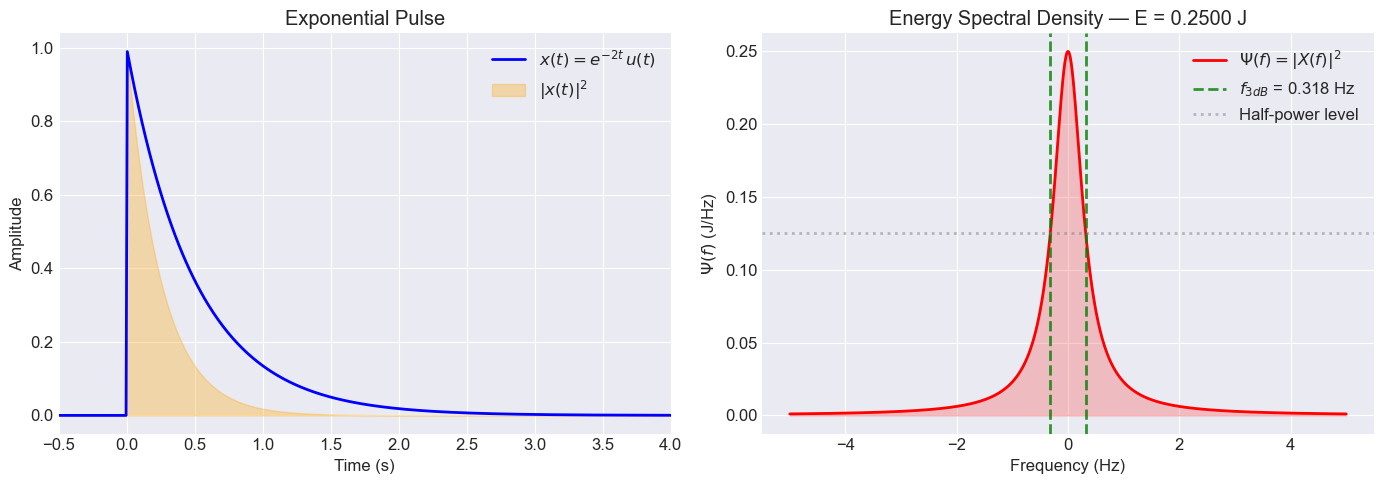


Fractional energy containment:
  Within ±1×f_3dB (±0.318 Hz): 50.0% of total energy
  Within ±2×f_3dB (±0.637 Hz): 70.5% of total energy
  Within ±5×f_3dB (±1.592 Hz): 87.4% of total energy
  Within ±10×f_3dB (±3.183 Hz): 93.7% of total energy


In [3]:
# Worked Example: ESD of an exponential pulse x(t) = e^{-at} u(t)
a = 2.0  # Decay rate (1/s)

# --- Analytical ---
# X(f) = 1 / (a + j2πf)
# |X(f)|² = 1 / (a² + (2πf)²)  →  Lorentzian shape
# Total energy: E = 1/(2a)
E_analytical = 1 / (2 * a)
f3dB = a / (2 * np.pi)
print(f"Exponential pulse: x(t) = e^(-{a}t) u(t)")
print(f"  ESD: Ψ(f) = 1 / ({a}² + (2πf)²)")
print(f"  3-dB bandwidth: f_3dB = a/(2π) = {f3dB:.4f} Hz")
print(f"  Total energy:   E = 1/(2a) = {E_analytical:.4f} J")

# --- Numerical verification ---
N = 8192
t = np.linspace(0, 10, N, endpoint=False)
dt = t[1] - t[0]
x = np.exp(-a * t)  # u(t) is implicit since t >= 0

E_time = np.sum(x**2) * dt
print(f"  Energy (numerical): {E_time:.4f} J")

# Compute ESD
f = np.linspace(-5, 5, 1000)
ESD_analytical = 1 / (a**2 + (2 * np.pi * f)**2)

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time domain
ax = axes[0]
t_plot = np.linspace(-0.5, 4, 500)
x_plot = np.where(t_plot >= 0, np.exp(-a * t_plot), 0)
ax.plot(t_plot, x_plot, 'b-', linewidth=2, label=r'$x(t) = e^{-2t}\,u(t)$')
ax.fill_between(t_plot, 0, x_plot**2, alpha=0.3, color='orange', label=r'$|x(t)|^2$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title('Exponential Pulse')
ax.set_xlim(-0.5, 4)
ax.legend()

# ESD
ax = axes[1]
ax.plot(f, ESD_analytical, 'r-', linewidth=2, label=r'$\Psi(f) = |X(f)|^2$')
ax.fill_between(f, 0, ESD_analytical, alpha=0.2, color='red')
ax.axvline(x=f3dB, color='green', linestyle='--', alpha=0.8, label=f'$f_{{3dB}}$ = {f3dB:.3f} Hz')
ax.axvline(x=-f3dB, color='green', linestyle='--', alpha=0.8)
ax.axhline(y=ESD_analytical[len(f)//2] / 2, color='gray', linestyle=':', alpha=0.5, label='Half-power level')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(r'$\Psi(f)$ (J/Hz)')
ax.set_title(f'Energy Spectral Density — E = {E_analytical:.4f} J')
ax.legend()

plt.tight_layout()
plt.show()

# Fractional energy in bandwidth
bw_fractions = [1, 2, 5, 10]
print(f"\nFractional energy containment:")
for bw in bw_fractions:
    f_bw = np.linspace(-bw * f3dB, bw * f3dB, 10000)
    ESD_bw = 1 / (a**2 + (2 * np.pi * f_bw)**2)
    E_bw = np.trapezoid(ESD_bw, f_bw)
    print(f"  Within ±{bw}×f_3dB (±{bw*f3dB:.3f} Hz): {100*E_bw/E_analytical:.1f}% of total energy")

---
## 3. Power Spectral Density (PSD)

**Power signals** have infinite energy but finite average power. Their Fourier transforms don't exist in the traditional sense, so we define:

**Power Spectral Density:**
$$S_x(f) = \lim_{T \to \infty} \frac{1}{T} |X_T(f)|^2$$

where $X_T(f)$ is the Fourier transform of the signal truncated to $[-T/2, T/2]$.

- Units: **Watts/Hz** (power per unit frequency)
- Total power: $P = \int_{-\infty}^{\infty} S_x(f)\,df$

**Example — Sinusoid:** $x(t) = A\cos(2\pi f_0 t)$
$$S_x(f) = \frac{A^2}{4}\left[\delta(f - f_0) + \delta(f + f_0)\right]$$

Power is concentrated at discrete frequencies $f = \pm f_0$, with total power $P = A^2/2$.

**White Noise:** $S_n(f) = N_0/2$ for all $f$ — constant power at every frequency ("white" like white light).

Sinusoid: x(t) = 3.0·cos(2π·60t)
  Analytical power: P = A²/2 = 4.50 W
  Time-domain check: P = mean(x²) = 4.5000 W


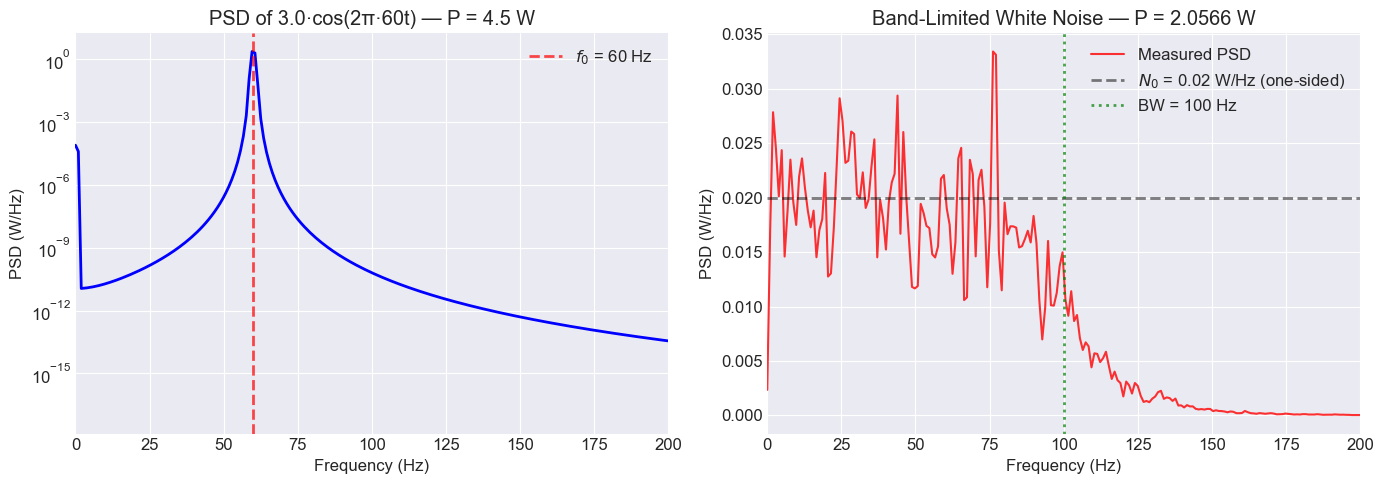


White noise: two-sided PSD = N₀/2 = 0.01 W/Hz at each frequency
  Welch (one-sided) shows N₀ = 0.02 W/Hz
  Expected power in BW = 100 Hz: P = N₀/2 × 2BW = 2.0 W
  Measured power: 2.0566 W

ESD vs PSD summary:
  ESD Ψ(f) = |X(f)|²     → Energy signals → Units: J/Hz
  PSD S(f) = lim |X_T|²/T → Power signals  → Units: W/Hz


In [4]:
# PSD of a sinusoid — numerical estimation via periodogram
A = 3.0       # Amplitude (V)
f0 = 60.0     # Frequency (Hz)
fs = 1000.0   # Sample rate (Hz)
duration = 10 # seconds

t = np.arange(0, duration, 1/fs)
x_sin = A * np.cos(2 * np.pi * f0 * t)

# Analytical power
P_analytical = A**2 / 2
print(f"Sinusoid: x(t) = {A}·cos(2π·{f0:.0f}t)")
print(f"  Analytical power: P = A²/2 = {P_analytical:.2f} W")
print(f"  Time-domain check: P = mean(x²) = {np.mean(x_sin**2):.4f} W")

# Estimate PSD using Welch's method
f_psd, Sxx = signal.welch(x_sin, fs=fs, nperseg=1024, scaling='density')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Sinusoid PSD
ax = axes[0]
ax.semilogy(f_psd, Sxx, 'b-', linewidth=2)
ax.axvline(x=f0, color='red', linestyle='--', alpha=0.7, label=f'$f_0$ = {f0:.0f} Hz')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (W/Hz)')
ax.set_title(f'PSD of {A}·cos(2π·{f0:.0f}t) — P = {P_analytical:.1f} W')
ax.set_xlim(0, 200)
ax.legend()

# Right: Band-limited white noise
# Two-sided PSD level: N₀/2 = 0.01 W/Hz
# For discrete white noise with two-sided PSD = N₀/2: variance σ² = (N₀/2)·fs
N0_half = 0.01  # N₀/2 in W/Hz
BW = 100        # Hz
noise = np.sqrt(N0_half * fs) * np.random.randn(len(t))
# Band-limit it
b, a_filt = signal.butter(4, BW / (fs/2), btype='low')
noise_bl = signal.lfilter(b, a_filt, noise)

# Welch returns one-sided PSD = 2 × (two-sided PSD) = N₀
f_noise, Snn = signal.welch(noise_bl, fs=fs, nperseg=1024, scaling='density')
P_noise = np.mean(noise_bl**2)
N0 = 2 * N0_half

ax = axes[1]
ax.plot(f_noise, Snn, 'r-', linewidth=1.5, alpha=0.8, label='Measured PSD')
ax.axhline(y=N0, color='k', linestyle='--', alpha=0.5,
           label=f'$N_0$ = {N0} W/Hz (one-sided)')
ax.axvline(x=BW, color='green', linestyle=':', alpha=0.7, label=f'BW = {BW} Hz')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (W/Hz)')
ax.set_title(f'Band-Limited White Noise — P = {P_noise:.4f} W')
ax.set_xlim(0, 200)
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nWhite noise: two-sided PSD = N₀/2 = {N0_half} W/Hz at each frequency")
print(f"  Welch (one-sided) shows N₀ = {N0} W/Hz")
print(f"  Expected power in BW = {BW} Hz: P = N₀/2 × 2BW = {N0_half * 2 * BW:.1f} W")
print(f"  Measured power: {P_noise:.4f} W")
print(f"\nESD vs PSD summary:")
print(f"  ESD Ψ(f) = |X(f)|²     → Energy signals → Units: J/Hz")
print(f"  PSD S(f) = lim |X_T|²/T → Power signals  → Units: W/Hz")

---
## 4. Correlation Functions

### Autocorrelation

Measures the similarity of a signal to a time-shifted version of itself.

**For energy signals:**
$$R_x(\tau) = \int_{-\infty}^{\infty} x(t)\,x(t - \tau)\,dt$$

**For power signals:**
$$R_x(\tau) = \lim_{T \to \infty} \frac{1}{T} \int_{-T/2}^{T/2} x(t)\,x(t - \tau)\,dt$$

**Key properties:**
- $R_x(0) = E$ (total energy) or $R_x(0) = P$ (average power)
- Even function: $R_x(-\tau) = R_x(\tau)$ for real signals
- Maximum at origin: $|R_x(\tau)| \leq R_x(0)$

### Wiener-Khinchin Theorem

Autocorrelation and spectral density are **Fourier transform pairs**:
$$R_x(\tau) \longleftrightarrow S_x(f)$$

This means: wide autocorrelation $\Rightarrow$ narrow spectrum, and vice versa.

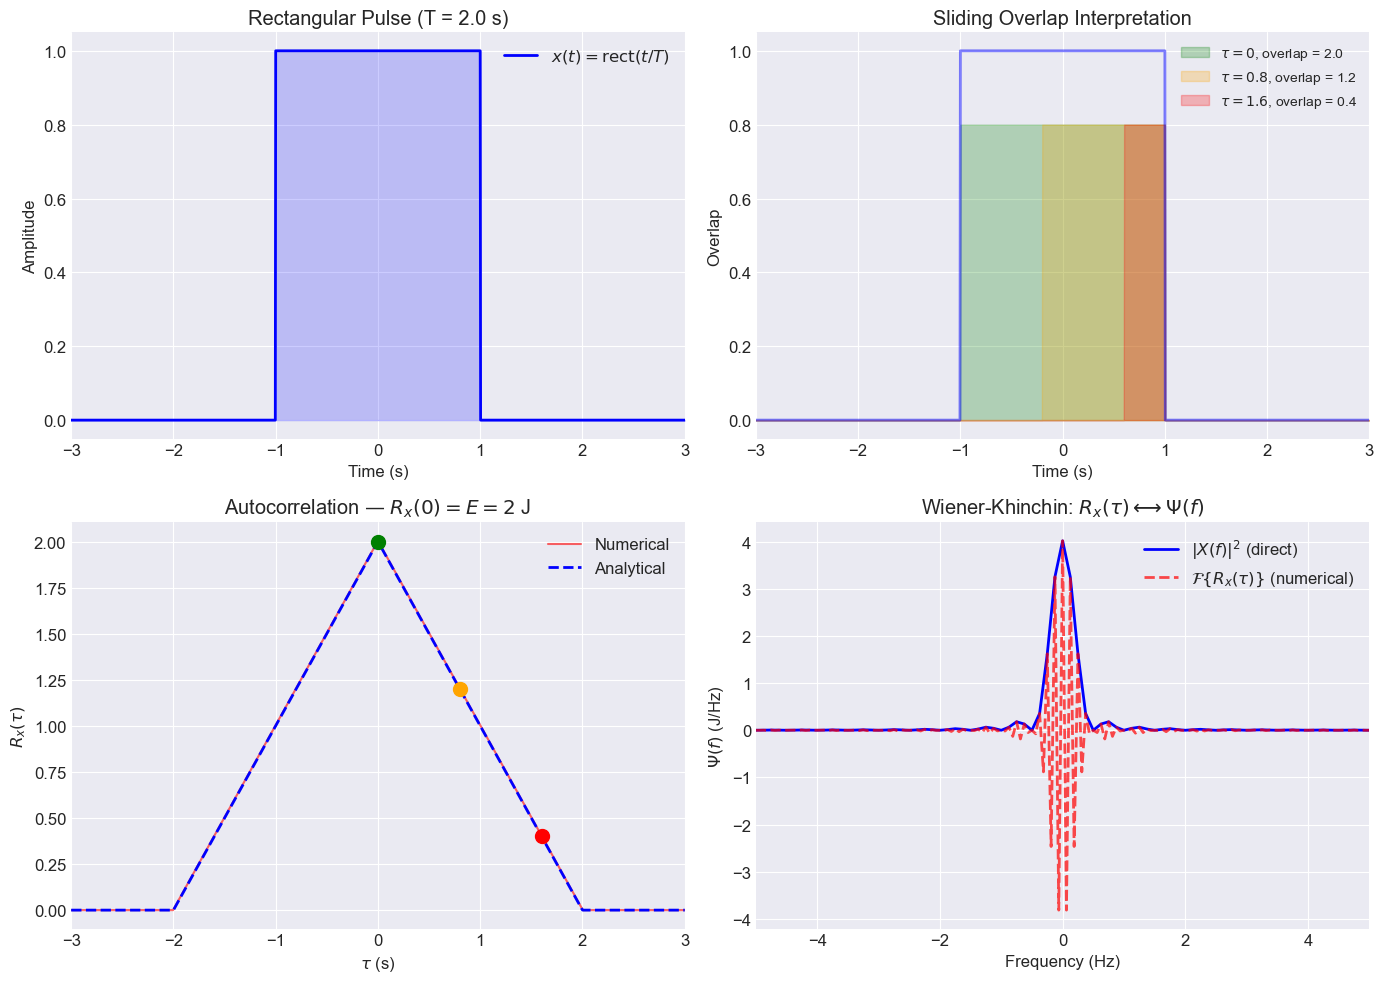

Autocorrelation properties verified:
  R_x(0) = 2.0 (total energy)
  R_x(τ) is symmetric: R_x(-1) = R_x(1) = 1.0
  |R_x(τ)| ≤ R_x(0) for all τ ✓

Wiener-Khinchin theorem: F{R_x(τ)} = |X(f)|² ✓


In [5]:
# Worked Example: Autocorrelation of a rectangular pulse
T_pulse = 2.0  # Pulse width (s)

# --- Analytical autocorrelation ---
# For rect(t/T): R(τ) = T - |τ| for |τ| < T, else 0  (triangle)
tau = np.linspace(-3, 3, 1000)
Rx_analytical = np.maximum(T_pulse - np.abs(tau), 0)

# --- Numerical: sliding overlap visualization ---
N = 2048
t = np.linspace(-4, 4, N, endpoint=False)
dt = t[1] - t[0]
x = np.where((t >= -T_pulse/2) & (t <= T_pulse/2), 1.0, 0.0)

# Compute autocorrelation via np.correlate
Rx_numerical = np.correlate(x, x, mode='full') * dt
tau_numerical = np.arange(-(N-1), N) * dt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: The pulse
ax = axes[0, 0]
ax.plot(t, x, 'b-', linewidth=2, label=r'$x(t) = \mathrm{rect}(t/T)$')
ax.fill_between(t, 0, x, alpha=0.2, color='blue')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Rectangular Pulse (T = {T_pulse} s)')
ax.set_xlim(-3, 3)
ax.legend()

# Top-right: Sliding overlap for three τ values
ax = axes[0, 1]
tau_examples = [0, 0.8, 1.6]
colors = ['green', 'orange', 'red']
for tau_ex, color in zip(tau_examples, colors):
    x_shifted = np.where((t >= -T_pulse/2 + tau_ex) & (t <= T_pulse/2 + tau_ex), 1.0, 0.0)
    overlap = x * x_shifted
    ax.fill_between(t, 0, overlap * 0.8, alpha=0.25, color=color,
                    label=rf'$\tau = {tau_ex}$, overlap = {max(T_pulse - abs(tau_ex), 0):.1f}')
ax.plot(t, x, 'b-', linewidth=2, alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Overlap')
ax.set_title('Sliding Overlap Interpretation')
ax.set_xlim(-3, 3)
ax.legend(fontsize=10)

# Bottom-left: Autocorrelation
ax = axes[1, 0]
ax.plot(tau_numerical, Rx_numerical, 'r-', linewidth=1.5, alpha=0.6, label='Numerical')
ax.plot(tau, Rx_analytical, 'b--', linewidth=2, label='Analytical')
for tau_ex, color in zip(tau_examples, colors):
    Rx_val = max(T_pulse - abs(tau_ex), 0)
    ax.plot(tau_ex, Rx_val, 'o', color=color, markersize=10, zorder=5)
ax.set_xlabel(r'$\tau$ (s)')
ax.set_ylabel(r'$R_x(\tau)$')
ax.set_title(f'Autocorrelation — $R_x(0) = E = {T_pulse:.0f}$ J')
ax.set_xlim(-3, 3)
ax.legend()

# Bottom-right: Wiener-Khinchin verification
# Compute ESD two ways: (1) |X(f)|² directly, (2) FFT of numerical autocorrelation
# Method 1: Direct |X(f)|²
X_direct = fft(x) * dt
freq_direct = fftfreq(N, dt)
ESD_direct = fftshift(np.abs(X_direct)**2)
freq_direct_shifted = fftshift(freq_direct)

# Method 2: FFT of autocorrelation R_x(τ)
N_Rx = len(Rx_numerical)
ESD_from_Rx_raw = np.real(fft(Rx_numerical) * (tau_numerical[1] - tau_numerical[0]))
freq_Rx = fftfreq(N_Rx, tau_numerical[1] - tau_numerical[0])
ESD_from_Rx = fftshift(ESD_from_Rx_raw)
freq_Rx_shifted = fftshift(freq_Rx)

ax = axes[1, 1]
ax.plot(freq_direct_shifted, ESD_direct, 'b-', linewidth=2, label=r'$|X(f)|^2$ (direct)')
ax.plot(freq_Rx_shifted, ESD_from_Rx, 'r--', linewidth=2, alpha=0.7,
        label=r'$\mathcal{F}\{R_x(\tau)\}$ (numerical)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(r'$\Psi(f)$ (J/Hz)')
ax.set_title('Wiener-Khinchin: $R_x(\\tau) \\longleftrightarrow \\Psi(f)$')
ax.set_xlim(-5, 5)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Autocorrelation properties verified:")
print(f"  R_x(0) = {T_pulse:.1f} (total energy)")
print(f"  R_x(τ) is symmetric: R_x(-1) = R_x(1) = {max(T_pulse - 1, 0):.1f}")
print(f"  |R_x(τ)| ≤ R_x(0) for all τ ✓")
print(f"\nWiener-Khinchin theorem: F{{R_x(τ)}} = |X(f)|² ✓")

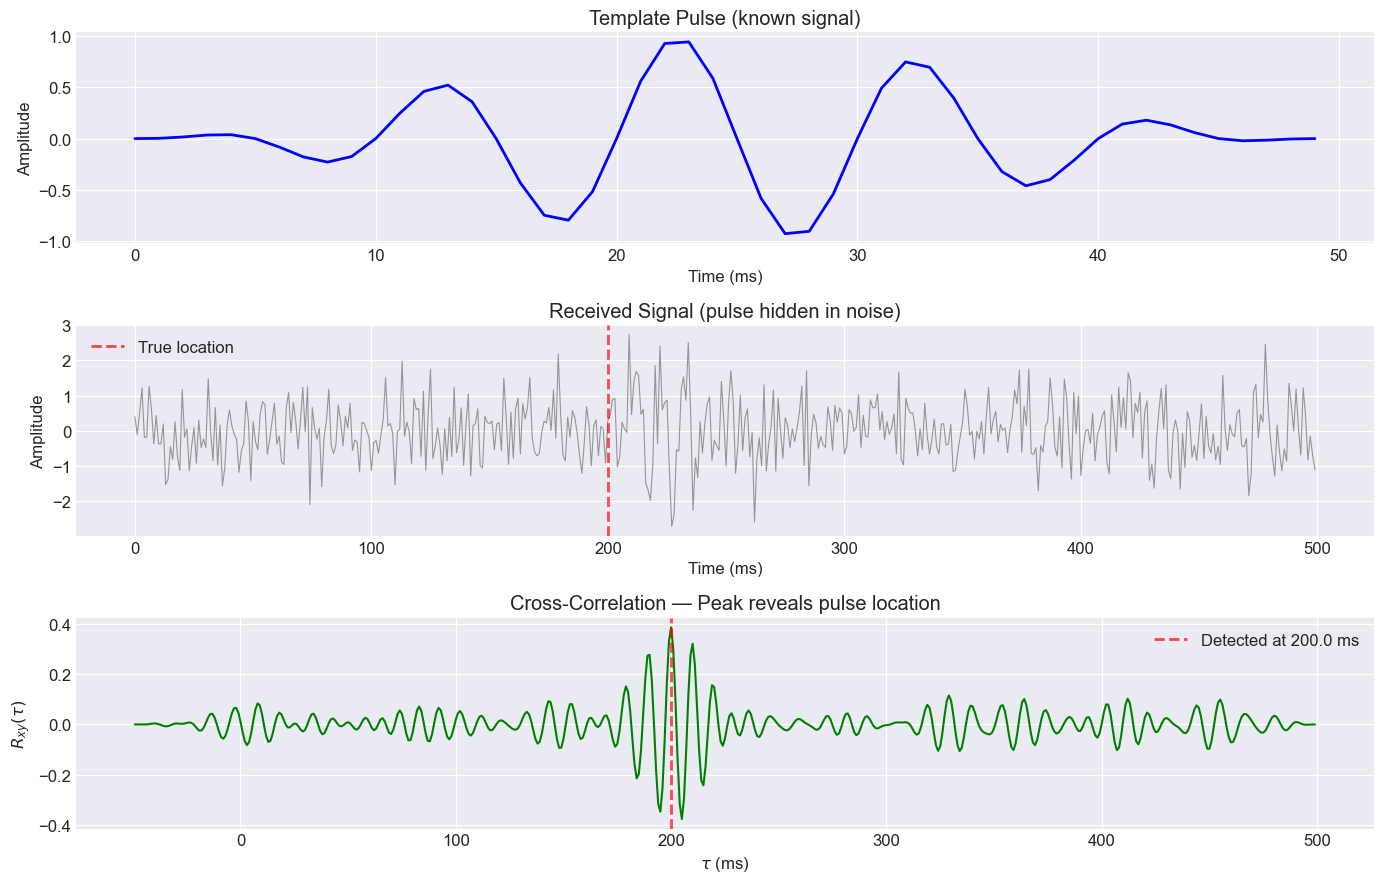

Cross-correlation detects the pulse at τ = 200.0 ms (true: 200.0 ms)
This is the basis of matched filter detection (Week 9).


In [6]:
# Cross-Correlation: detecting a known pulse in a noisy signal
np.random.seed(42)

# Template pulse (known signal to detect)
fs = 1000
t_pulse = np.arange(0, 0.05, 1/fs)  # 50 ms pulse
template = np.sin(2 * np.pi * 100 * t_pulse) * np.hanning(len(t_pulse))

# Received signal: template buried in noise at an unknown time
t_rx = np.arange(0, 0.5, 1/fs)
rx = 0.8 * np.random.randn(len(t_rx))
# Insert template at t = 0.2 s
insert_idx = int(0.2 * fs)
rx[insert_idx:insert_idx + len(template)] += 2.0 * template

# Cross-correlation to find the pulse
Rxy = np.correlate(rx, template, mode='full') / len(template)
tau_cc = np.arange(-(len(template)-1), len(rx)) / fs

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

ax = axes[0]
ax.plot(t_pulse * 1000, template, 'b-', linewidth=2)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude')
ax.set_title('Template Pulse (known signal)')

ax = axes[1]
ax.plot(t_rx * 1000, rx, 'gray', linewidth=0.8, alpha=0.8)
ax.axvline(x=200, color='red', linestyle='--', alpha=0.7, label='True location')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude')
ax.set_title('Received Signal (pulse hidden in noise)')
ax.legend()

ax = axes[2]
ax.plot(tau_cc * 1000, Rxy, 'green', linewidth=1.5)
peak_idx = np.argmax(np.abs(Rxy))
peak_tau = tau_cc[peak_idx]
ax.axvline(x=peak_tau * 1000, color='red', linestyle='--', alpha=0.7,
           label=f'Detected at {peak_tau*1000:.1f} ms')
ax.set_xlabel(r'$\tau$ (ms)')
ax.set_ylabel(r'$R_{xy}(\tau)$')
ax.set_title('Cross-Correlation — Peak reveals pulse location')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Cross-correlation detects the pulse at τ = {peak_tau*1000:.1f} ms (true: 200.0 ms)")
print(f"This is the basis of matched filter detection (Week 9).")

---
## 5. Spectral Analysis Applications

### Bandwidth of Digital Signals

A binary NRZ (Non-Return-to-Zero) pulse train uses rectangular pulses of duration $T_b$ (one bit period).

- Individual pulse spectrum: $T_b \operatorname{sinc}(f T_b)$
- First null at $f = 1/T_b$
- Bit rate: $R_b = 1/T_b$ bits/sec
- **Rule of thumb:** Null-to-null bandwidth $\approx 2 R_b$ for baseband NRZ

*Convention: $\operatorname{sinc}(x) = \sin(\pi x)/(\pi x)$ per Haykin & Moher Eq. 2.9*

### Modulated Signal Spectrum

When a baseband signal with bandwidth $W$ modulates a carrier at $f_c$:
- **DSB:** Bandwidth = $2W$ (spectrum shifts to $f_c \pm W$)
- **SSB:** Bandwidth = $W$ (one sideband only)

Spectral efficiency = bits/sec per Hz of bandwidth.

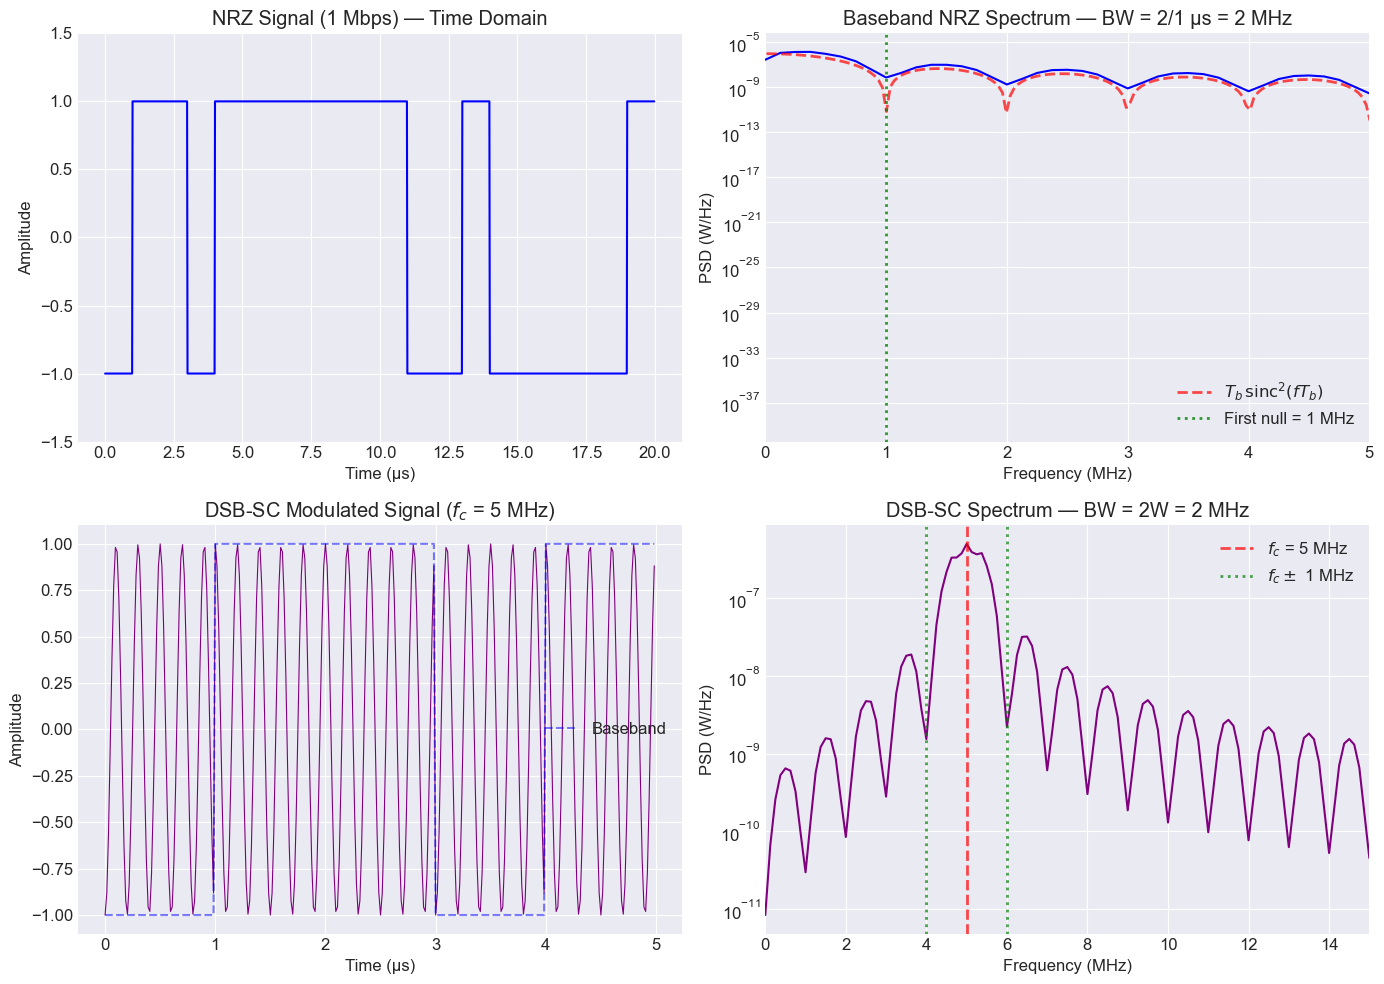

NRZ Signal (1 Mbps):
  Bit duration: T_b = 1 μs
  Baseband null-to-null BW: 2/T_b = 2 MHz
  DSB-SC modulated BW: 2 × baseband W = 2 MHz centered at f_c

Filter design trade-off:
  Too narrow → signal distortion (ISI)
  Too wide   → excess noise captured
  Optimal    → Nyquist criterion (Week 9)


In [7]:
# Application: NRZ digital signal spectrum and modulated signal spectrum
np.random.seed(0)

Rb = 1e6       # 1 Mbps bit rate
Tb = 1 / Rb    # Bit duration (1 μs)
num_bits = 200

# Generate random NRZ signal
bits = 2 * np.random.randint(0, 2, num_bits) - 1  # ±1
samples_per_bit = 64
t_nrz = np.arange(num_bits * samples_per_bit) / (samples_per_bit * Rb)
x_nrz = np.repeat(bits, samples_per_bit)

# Compute PSD via Welch
fs_nrz = samples_per_bit * Rb
f_nrz, Pxx = signal.welch(x_nrz, fs=fs_nrz, nperseg=512, scaling='density')

# Also compute modulated version (DSB-SC at 5 MHz carrier)
fc = 5e6
t_mod = t_nrz
carrier = np.cos(2 * np.pi * fc * t_mod)
x_mod = x_nrz * carrier
f_mod, Pxx_mod = signal.welch(x_mod, fs=fs_nrz, nperseg=512, scaling='density')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: NRZ time domain (first 20 bits)
ax = axes[0, 0]
show_bits = 20
t_show = t_nrz[:show_bits * samples_per_bit] * 1e6
x_show = x_nrz[:show_bits * samples_per_bit]
ax.plot(t_show, x_show, 'b-', linewidth=1.5)
ax.set_xlabel('Time (μs)')
ax.set_ylabel('Amplitude')
ax.set_title(f'NRZ Signal ({Rb/1e6:.0f} Mbps) — Time Domain')
ax.set_ylim(-1.5, 1.5)

# Top-right: NRZ PSD with bandwidth annotations
ax = axes[0, 1]
f_plot = f_nrz / 1e6
ax.semilogy(f_plot, Pxx, 'b-', linewidth=1.5)
# Overlay theoretical sinc² envelope
# np.sinc(x) computes sin(πx)/(πx), so np.sinc(f*Tb) = sinc(fTb)
f_theory = np.linspace(0.01, max(f_plot), 1000)
Pxx_theory = Tb * np.sinc(f_theory * 1e6 * Tb)**2
ax.semilogy(f_theory, Pxx_theory, 'r--', linewidth=2, alpha=0.7, label=r'$T_b\,\mathrm{sinc}^2(f T_b)$')
ax.axvline(x=Rb/1e6, color='green', linestyle=':', alpha=0.8, label=f'First null = {Rb/1e6:.0f} MHz')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('PSD (W/Hz)')
ax.set_title(f'Baseband NRZ Spectrum — BW = 2/{Tb*1e6:.0f} μs = {2*Rb/1e6:.0f} MHz')
ax.set_xlim(0, 5)
ax.legend()

# Bottom-left: Modulated time domain (zoom to 5 bits)
ax = axes[1, 0]
show_mod = 5
t_mod_show = t_mod[:show_mod * samples_per_bit] * 1e6
x_mod_show = x_mod[:show_mod * samples_per_bit]
ax.plot(t_mod_show, x_mod_show, 'purple', linewidth=0.8)
ax.plot(t_mod_show, x_nrz[:show_mod * samples_per_bit], 'b--', linewidth=1.5, alpha=0.5, label='Baseband')
ax.set_xlabel('Time (μs)')
ax.set_ylabel('Amplitude')
ax.set_title(f'DSB-SC Modulated Signal ($f_c$ = {fc/1e6:.0f} MHz)')
ax.legend()

# Bottom-right: Modulated PSD
ax = axes[1, 1]
f_mod_plot = f_mod / 1e6
ax.semilogy(f_mod_plot, Pxx_mod, 'purple', linewidth=1.5)
ax.axvline(x=fc/1e6, color='red', linestyle='--', alpha=0.7, label=f'$f_c$ = {fc/1e6:.0f} MHz')
ax.axvline(x=(fc - Rb)/1e6, color='green', linestyle=':', alpha=0.7)
ax.axvline(x=(fc + Rb)/1e6, color='green', linestyle=':', alpha=0.7, label=f'$f_c \\pm$ {Rb/1e6:.0f} MHz')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('PSD (W/Hz)')
ax.set_title(f'DSB-SC Spectrum — BW = 2W = {2*Rb/1e6:.0f} MHz')
ax.set_xlim(0, 15)
ax.legend()

plt.tight_layout()
plt.show()

print(f"NRZ Signal ({Rb/1e6:.0f} Mbps):")
print(f"  Bit duration: T_b = {Tb*1e6:.0f} μs")
print(f"  Baseband null-to-null BW: 2/T_b = {2*Rb/1e6:.0f} MHz")
print(f"  DSB-SC modulated BW: 2 × baseband W = {2*Rb/1e6:.0f} MHz centered at f_c")
print(f"\nFilter design trade-off:")
print(f"  Too narrow → signal distortion (ISI)")
print(f"  Too wide   → excess noise captured")
print(f"  Optimal    → Nyquist criterion (Week 9)")

---
## Summary

| Concept | Formula | Units | Key Idea |
|---------|---------|-------|----------|
| **Parseval's Theorem** | $\int \lvert x(t)\rvert^2 dt = \int \lvert X(f)\rvert^2 df$ | J | Energy conserved across domains |
| **Energy Spectral Density** | $\Psi(f) = \lvert X(f)\rvert^2$ | J/Hz | Energy distribution vs. frequency |
| **Power Spectral Density** | $S(f) = \lim_{T\to\infty} \frac{1}{T}\lvert X_T(f)\rvert^2$ | W/Hz | Power distribution vs. frequency |
| **Autocorrelation** | $R_x(\tau) = \int x(t)\,x(t-\tau)\,dt$ | J or W | Self-similarity at lag $\tau$ |
| **Cross-Correlation** | $R_{xy}(\tau) = \int x(t)\,y(t-\tau)\,dt$ | — | Similarity between two signals |
| **Wiener-Khinchin** | $R_x(\tau) \longleftrightarrow S_x(f)$ | — | Autocorrelation ↔ spectral density |
| **NRZ Bandwidth** | $\text{BW} \approx 2/T_b = 2R_b$ | Hz | Null-to-null for rectangular pulses |
| **DSB Bandwidth** | $\text{BW} = 2W$ | Hz | Baseband $W$ doubles after modulation |

**Key Takeaways:**
1. Parseval's theorem lets you compute energy in whichever domain is easier
2. ESD and PSD tell you *where* energy/power sits in the spectrum — essential for filter design
3. Autocorrelation at $\tau = 0$ gives total energy (or average power)
4. Cross-correlation finds a known signal buried in noise (matched filtering)
5. The Wiener-Khinchin theorem connects time-domain correlation to frequency-domain spectra
6. Digital signals need bandwidth proportional to bit rate — modulation doubles it

**Next Lesson:** Amplitude Modulation Theory — DSB-SC, Full AM, envelope detection